<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 8</h3>
    <h3>Ejercicio 1</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
</div>

Chronos

Github para mayor detalle: https://github.com/amazon-science/chronos-forecasting

# Parte uno, ejemplos de Chronos.

Librerias a instalar para este ejercicio

In [ ]:
! pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-dhdb7au2
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-dhdb7au2
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 32111085d85de6cc17d0ea4dd08adba324f57590
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.1 MB/s eta 0:00:00
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.2.2-py3-none-any.whl size=74105 sha256=27238339adb2760139250701a2e06fc232e5562207fac2eb350f83b949963467
  Stored in directory: /tmp/pip-ephem-wheel-cache-y1qjeu0h/wheels/b9/a6/b5/75fca7306751a

In [ ]:
## Librerias
import yfinance as yf
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Caso 1. Pronostico MSFT

Hugging Face tiene un gran repositorio en línea de modelos de IA ya entrenados
=  [Ingresar aqui](https://huggingface.co/) . <br>

Orientados entre otros temas a :

- Procesamiento de lenguaje natural (NLP)
- Series temporales

Su producto mas conocido es la libreria Transformers. Chronos distribuye modelos preentrenados de forma muy similar a Hugging Face

In [ ]:
## Parametros
pipeline = ChronosPipeline.from_pretrained(
    #"amazon/chronos-t5-small",
    "amazon/chronos-t5-large",
    device_map="auto",  # "cpu" o "mps" para Apple Silicon  cuda
    torch_dtype=torch.bfloat16,
)


'''
Breves comentarios =

1- Se inicializa una instancia ChronosPipeline usando un modelo preentrenado.
2-chronos-t5-large --> nombre de un modelo preentrenado . Tb podria ser amazon/chronos-t5-small
3- device_map le dice al modelo en que dispositivo debe cargarse y ejecutarse ( opciones = cuda --> Intenta usar GPU NVIDIA / cpu --> usa procesador cpu / auto --> detecta automaticamente  / mps --> usa gpu integrada solo en macOS)
4- torch_dtype aqui esa configurada de la forma mas liviana de representar numeros. float32 es mas pesado

Modelo: chronos-t5-tiny	--> Parametros 8 Millones
Modelo: chronos-t5-mini --> Parametros	20 M.
Modelo: chronos-t5-small --> Parametros	46 M.
Modelo: chronos-t5-base --> Parametros	200 M.
Modelo: chronos-t5-large --> Parametros	710 M.


'''

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

'\nBreves comentarios =\n\n1- Se inicializa una instancia ChronosPipeline usando un modelo preentrenado.\n2-chronos-t5-large --> nombre de un modelo preentrenado . Tb podria ser amazon/chronos-t5-small\n3- device_map le dice al modelo en que dispositivo debe cargarse y ejecutarse ( opciones = cuda --> Intenta usar GPU NVIDIA / cpu --> usa procesador cpu / auto --> detecta automaticamente  / mps --> usa gpu integrada solo en macOS)\n4- torch_dtype aqui esa configurada de la forma mas liviana de representar numeros. float32 es mas pesado\n\nModelo: chronos-t5-tiny\t--> Parametros 8 Millones\nModelo: chronos-t5-mini --> Parametros\t20 M.\nModelo: chronos-t5-small --> Parametros\t46 M.\nModelo: chronos-t5-base --> Parametros\t200 M.\nModelo: chronos-t5-large --> Parametros\t710 M.\n\n\n'

In [ ]:
# trabajamos con los datos de accion de Microsoft

msft = yf.Ticker("MSFT")

hist = msft.history(period="2y").reset_index().rename(columns={'Date':'ds','Open':'y'})
hist['ds'] = hist['ds'].dt.strftime('%Y-%m-%d')
hist['cap']=hist.y.rolling(window=5).mean().fillna(method='bfill')*1.20  # Aca se toma el promedio movil de los últimos 5 dias de el precio de apertura y le suma un 20% para obtener el techo.
hist['floor']=hist.y.rolling(window=5).mean().fillna(method='bfill')*0.80 # Idem piso

In [ ]:
hist.tail()

,ds,y,High,Low,Close,Volume,Dividends,Stock Splits,cap,floor
496,2026-04-20,421.149994,423.329987,416.299988,418.070007,27582200,0.0,0.0,492.420000,328.280000
497,2026-04-21,420.239990,427.179993,417.200012,424.160004,32048500,0.0,0.0,500.176794,333.451196
498,2026-04-22,426.190002,433.700012,423.670013,432.920013,29378200,0.0,0.0,506.942395,337.961597
499,2026-04-23,419.890015,423.660004,411.410004,415.750000,38308000,0.0,0.0,506.949602,337.966401
500,2026-04-24,416.984985,424.890015,415.799988,424.619995,27161742,0.0,0.0,505.069197,336.712798


In [ ]:
## Parametros de prediccion
step_to_predict= 20  # Da la cantidad de pasos hacia adelante que vamos a predecir
samples_to_consider= 5 # Simula 5 futuros posibles para entender mejor lo que puede pasar

In [ ]:
## Proyeccion
forecast = pipeline.predict(
    torch.tensor(hist["y"]),
    prediction_length=step_to_predict,
    num_samples=samples_to_consider,
)

forecast_index = range(len(hist), len(hist) + step_to_predict)
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

In [ ]:
predicted_mean = forecast.mean(axis=0)

In [ ]:
print(predicted_mean)

tensor([[422.7926, 422.7926, 419.5651, 419.5651, 416.3377, 416.3377, 416.3377,
         416.3377, 422.7926, 422.7926, 426.0200, 422.7926, 422.7926, 429.2474,
         432.4748, 435.7022, 432.4748, 438.9297, 435.7022, 432.4748],
        [422.7926, 413.1103, 409.8829, 403.4280, 416.3377, 419.5651, 419.5651,
         429.2474, 435.7022, 438.9297, 435.7022, 432.4748, 435.7022, 438.9297,
         442.1571, 435.7022, 435.7022, 435.7022, 435.7022, 438.9297],
        [419.5651, 426.0200, 426.0200, 429.2474, 429.2474, 429.2474, 432.4748,
         438.9297, 445.3845, 445.3845, 429.2474, 438.9297, 432.4748, 445.3845,
         445.3845, 442.1571, 445.3845, 442.1571, 442.1571, 442.1571],
        [409.8829, 409.8829, 426.0200, 426.0200, 426.0200, 432.4748, 432.4748,
         435.7022, 442.1571, 435.7022, 438.9297, 435.7022, 429.2474, 432.4748,
         438.9297, 442.1571, 422.7926, 419.5651, 432.4748, 419.5651],
        [400.2006, 390.5183, 387.2909, 387.2909, 400.2006, 393.7458, 387.2909,
         

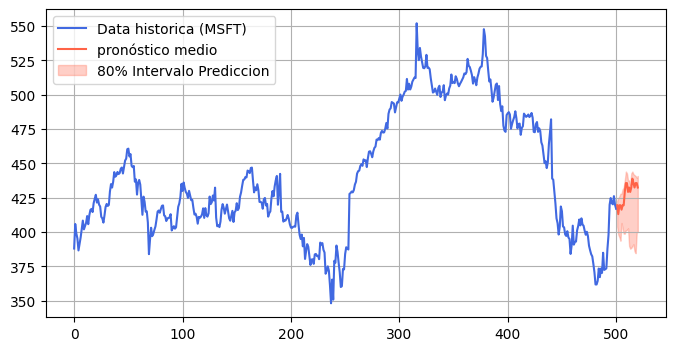

In [ ]:
# Grafico
plt.figure(figsize=(8, 4))
plt.plot(hist["y"], color="royalblue", label="Data historica (MSFT)")
plt.plot(forecast_index, median, color="tomato", label="pronóstico medio")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% Intervalo Prediccion")
plt.legend()
plt.grid()
plt.show()

## Caso 2 - Pronostico Transito Gobierno de la ciudad de buenos aires, vehiculos que pasan por los peajes de CABA - [Link relacionado de Base de Datos](https://buenosaires.gob.ar/innovacionytransformaciondigital/datos-abiertos-de-buenos-aires)

In [ ]:
# ENERO 2024
URL = 'https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/refs/heads/main/Transito%20Enero%202024.csv'
df_mes01 = pd.read_csv(URL, sep=";")

#Nuevos nombres de las columnas
nuevos_nombres = ['Fecha', 'Hora', 'Cat_Cobrada','ID_Peaje', 'Observacion', 'Sentido', 'Tipo_Cobro', 'Pasos' ]
df_mes01.columns = nuevos_nombres

df_mes01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247951 entries, 0 to 247950
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Fecha        247951 non-null  object 
 1   Hora         247951 non-null  int64  
 2   Cat_Cobrada  247951 non-null  object 
 3   ID_Peaje     247951 non-null  object 
 4   Observacion  247951 non-null  object 
 5   Sentido      247951 non-null  object 
 6   Tipo_Cobro   247951 non-null  object 
 7   Pasos        247951 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 15.1+ MB


In [ ]:
df_mes01['Fecha'] = pd.to_datetime(df_mes01['Fecha'], format="%d/%m/%Y", errors='coerce')

In [ ]:
def normalizar_hora(valor):
    valor_str = str(valor)
    if len(valor_str) == 1:
        return '0' + valor_str + '00'
    elif len(valor_str) == 2:
        return valor_str + '00'
    elif len(valor_str) == 3:
        return '0' + valor_str
    elif len(valor_str) == 4:
        return valor_str
    else:
        return None


df_mes01['Hora'] = df_mes01['Hora'].apply(normalizar_hora)
df_mes01['Hora'] = pd.to_datetime(df_mes01['Hora'], format='%H%M', errors='coerce').dt.time

In [ ]:
type(df_mes01['Hora'].iloc[0])

datetime.time

In [ ]:
df_mes01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247951 entries, 0 to 247950
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Fecha        247918 non-null  datetime64[ns]
 1   Hora         247951 non-null  object        
 2   Cat_Cobrada  247951 non-null  object        
 3   ID_Peaje     247951 non-null  object        
 4   Observacion  247951 non-null  object        
 5   Sentido      247951 non-null  object        
 6   Tipo_Cobro   247951 non-null  object        
 7   Pasos        247951 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 15.1+ MB


In [ ]:
df_mes01['Hora'] = df_mes01['Hora'].astype(str)

fecha_hora_str = df_mes01['Fecha'].dt.strftime('%d/%m/%Y') + ' ' + df_mes01['Hora']

df_mes01['FechaHora'] = pd.to_datetime(fecha_hora_str, format='%d/%m/%Y %H:%M:%S')

In [ ]:
valores_unicos_2 = df_mes01['Fecha'].unique()
print(valores_unicos_2)

<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-02 00:00:00', '2024-01-03 00:00:00',
 '2024-01-04 00:00:00', '2024-01-05 00:00:00', '2024-01-06 00:00:00',
 '2024-01-07 00:00:00', '2024-01-08 00:00:00', '2024-01-09 00:00:00',
 '2024-01-10 00:00:00', '2024-01-11 00:00:00', '2024-01-12 00:00:00',
 '2024-01-13 00:00:00', '2024-01-14 00:00:00', '2024-01-15 00:00:00',
 '2024-01-16 00:00:00', '2024-01-17 00:00:00', '2024-01-18 00:00:00',
 '2024-01-19 00:00:00', '2024-01-20 00:00:00', '2024-01-21 00:00:00',
 '2024-01-22 00:00:00', '2024-01-23 00:00:00', '2024-01-24 00:00:00',
 '2024-01-25 00:00:00', '2024-01-26 00:00:00', '2024-01-27 00:00:00',
 '2024-01-28 00:00:00', '2024-01-29 00:00:00', '2024-01-30 00:00:00',
 '2024-01-31 00:00:00',                 'NaT']
Length: 32, dtype: datetime64[ns]


In [ ]:
df_agrupado = df_mes01.groupby('FechaHora', as_index=True)['Pasos'].sum().reset_index()

df_agrupado.head()

,FechaHora,Pasos
0,2024-01-01 00:00:00,5935.0
1,2024-01-01 01:00:00,4385.0
2,2024-01-01 02:00:00,2534.0
3,2024-01-01 03:00:00,2216.0
4,2024-01-01 04:00:00,3325.0


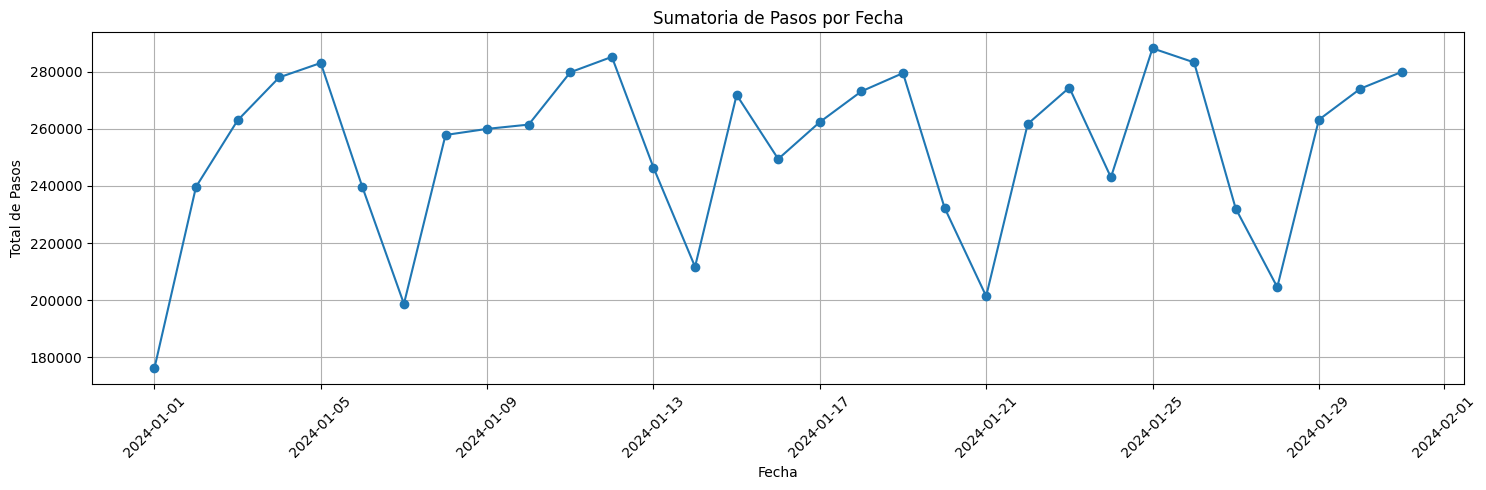

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_agrupado_fecha = df_mes01.groupby('Fecha')['Pasos'].sum().reset_index()

df_agrupado_fecha = df_agrupado_fecha.sort_values('Fecha')

plt.figure(figsize=(15, 5))
plt.plot(df_agrupado_fecha['Fecha'], df_agrupado_fecha['Pasos'], marker='o')
plt.title('Sumatoria de Pasos por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Total de Pasos')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

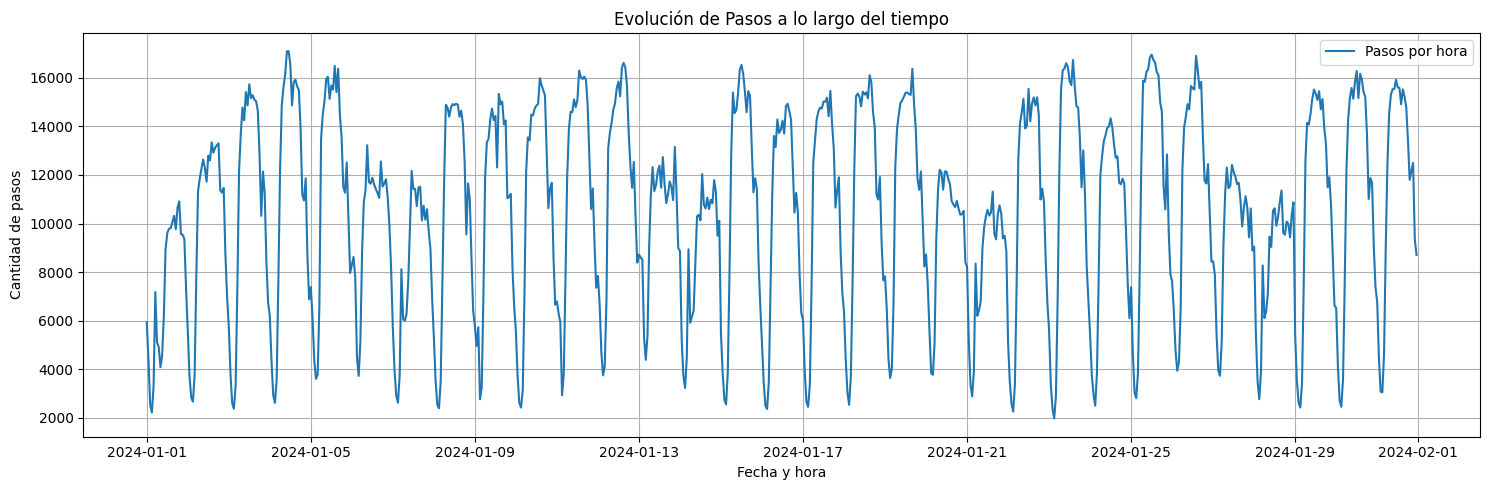

In [ ]:
import matplotlib.pyplot as plt

df_agrupado = df_agrupado.sort_values('FechaHora')

plt.figure(figsize=(15, 5))
plt.plot(df_agrupado['FechaHora'], df_agrupado['Pasos'], label='Pasos por hora')

plt.xlabel('Fecha y hora')
plt.ylabel('Cantidad de pasos')
plt.title('Evolución de Pasos a lo largo del tiempo')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import torch
from chronos import BaseChronosPipeline

In [ ]:
n_test = 24
df_agrupado_train = df_agrupado[:-n_test]
df_agrupado_test = df_agrupado[-n_test:]

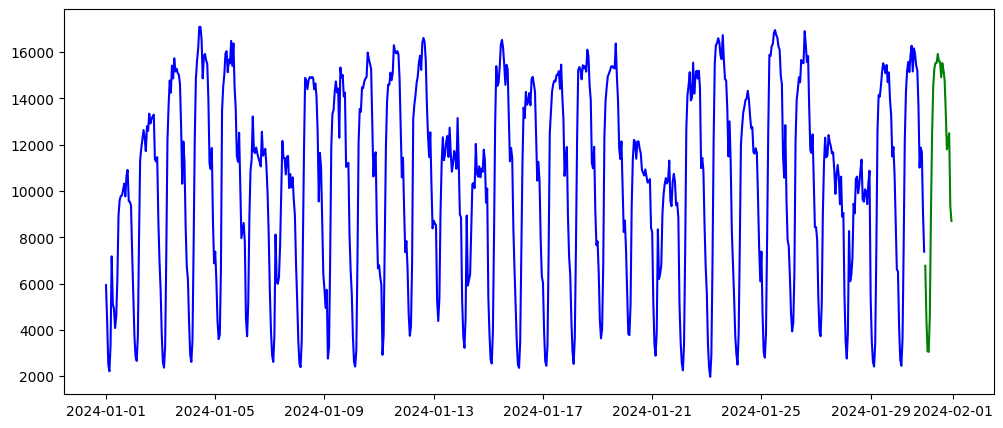

In [ ]:
fechas_train = df_agrupado_train["FechaHora"]
fechas_test = df_agrupado_test["FechaHora"]

plt.figure(figsize=(12, 5))

plt.plot(fechas_train, df_agrupado_train["Pasos"], label="Entrenamiento", color="blue")
plt.plot(fechas_test, df_agrupado_test["Pasos"], label="Test real", color="green")

In [ ]:
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [ ]:
quantiles, mean = pipeline.predict_quantiles(
    torch.tensor(df_agrupado_train["Pasos"]), # Pass as the 'inputs' positional argument
    prediction_length=24,
    quantile_levels=[0.1, 0.5, 0.9],
)

'''
El codigo nos da =
quantiles[0.1] --> tensor de 24 valores representando el cuantil 10% para cada paso futuro.
quantiles[0.5] = idem pero para la mediana.
quantiles[0.9]= para el cuantil 90%.
mean: tensor de 24 valores representando el valor medio predicho para cada paso futuro.
'''

'\nEl codigo nos da =\nquantiles[0.1] --> tensor de 24 valores representando el cuantil 10% para cada paso futuro.\nquantiles[0.5] = idem pero para la mediana.\nquantiles[0.9]= para el cuantil 90%.\nmean: tensor de 24 valores representando el valor medio predicho para cada paso futuro.\n'

In [ ]:
# Aca imprime la ayuda del metodo
from chronos import ChronosPipeline, ChronosBoltPipeline

print(ChronosPipeline.predict.__doc__)  # for Chronos models
print(ChronosBoltPipeline.predict.__doc__)  # for Chronos-Bolt models


        Get forecasts for the given time series.

        Refer to the base method (``BaseChronosPipeline.predict``)
        for details on shared parameters.

        Additional parameters
        ---------------------
        num_samples
            Number of sample paths to predict. Defaults to what
            specified in ``self.model.config``.
        temperature
            Temperature to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_k
            Top-k parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_p
            Top-p parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        limit_prediction_length
            Force prediction length smaller or equal than the
            built-in prediction length from the model. False by
            default. When true, fail loudly if longer p

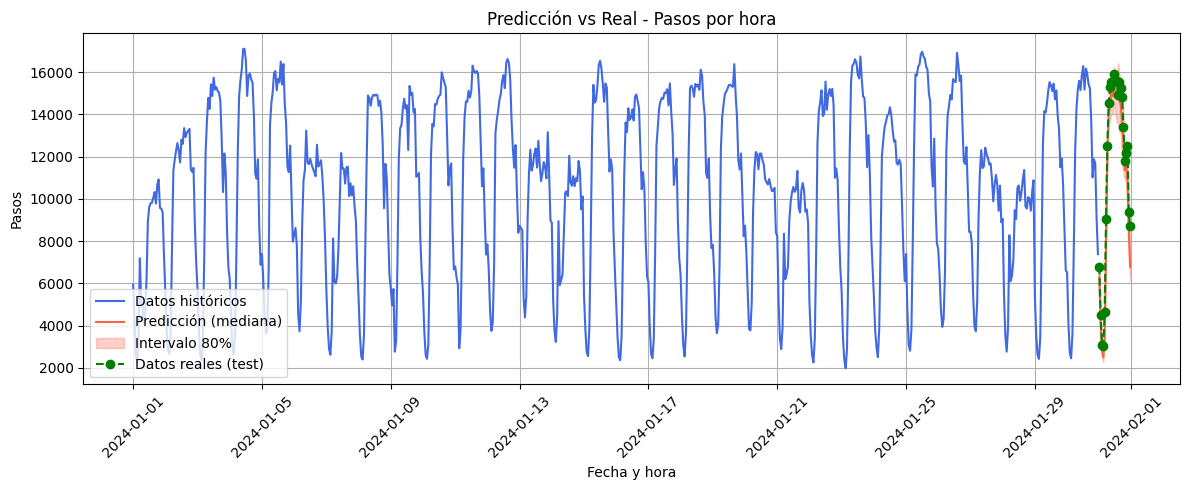

In [ ]:
import matplotlib.pyplot as plt
from datetime import timedelta


low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

actual = df_agrupado_test["Pasos"].values

last_train_date = df_agrupado_train["FechaHora"].iloc[-1]
forecast_dates = [last_train_date + timedelta(hours=i) for i in range(1, len(median) + 1)]

plt.figure(figsize=(12, 5))

plt.plot(df_agrupado_train["FechaHora"], df_agrupado_train["Pasos"], color="royalblue", label="Datos históricos")
plt.plot(forecast_dates, median, color="tomato", label="Predicción (mediana)")
plt.fill_between(forecast_dates, low, high, color="tomato", alpha=0.3, label="Intervalo 80%")
plt.plot(forecast_dates, actual, color="green", linestyle="--", marker="o", label="Datos reales (test)")

plt.legend()
plt.grid()
plt.title("Predicción vs Real - Pasos por hora")
plt.xlabel("Fecha y hora")
plt.ylabel("Pasos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Parte dos, modelar con lo aprendido .


Utilizando el modelo preentrenado de chronos-forecasting, se pide construir un modelo de forecasting aplicado a una serie temporal a eleccion.

El trabajo tiene que

-Obtener y preparar la serie temporal.
-Aplicar el modelo para generar predicciones a futuro.
-Visualizar los resultados
-Interpretar los resultados obtenidos y discutir su validez.

Gracias!

In [ ]:
# Arranquen con el codigo....